# 10 — Institutional Benchmarking

**Chapter 12 companion.** This notebook brings the book together. It combines peer
groups (notebook 05), shrunk graduation rates (notebook 04), and robust
standardisation (notebook 02) into a benchmarking scorecard for one focal
institution. It then tests the property most scorecards never report: how much the
ranking depends on the weights someone chose.

| | |
|---|---|
| Inputs | `data/analytic/institutions_2023.parquet`, `peer_groups.parquet` (required, notebook 05), `shrunk_grad_rates.parquet` (optional, notebook 04) |
| Focal institution | University of Colorado Denver/Anschutz Medical Campus (UNITID 126562); change `FOCAL_UNITID` to benchmark another |
| Methods | Within-peer robust z-scores, winsorising, a coverage rule for composites, Dirichlet weight sensitivity, rank intervals |
| Outputs | `reports/scorecards/scorecard_<UNITID>.csv`, `reports/figures/10_scorecard.png` |

A composite score is a summary for discussion, not a measure of institutional
quality. Each indicator carries a direction, a definition, and a known limitation,
and the scorecard reports all three.

In [1]:
import os
import sys
import warnings
from pathlib import Path

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ipeds_utils as iu

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({
    "figure.dpi": 100, "figure.figsize": (8, 4.2),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 10,
})

ANALYTIC = Path("../data/analytic")
FIGURES = Path("../reports/figures")
ANALYTIC.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 20231  # one seed for every stochastic step, so reruns reproduce exactly
rng = np.random.default_rng(SEED)


def save(name):
    """Save the current figure to reports/figures and display it."""
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"ipeds_utils {iu.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

ipeds_utils 1.1.0 | pandas 3.0.5 | numpy 2.5.3


In [2]:
source = ANALYTIC / "institutions_2023.parquet"
if not source.exists():
    raise FileNotFoundError("Run 01_ingest_clean_deidentify.ipynb first; it builds the analytic table.")

inst = pd.read_parquet(source)
inst = inst[inst["IN_UNIVERSE"]].copy()
print(f"{len(inst):,} institutions in the analysis universe")

5,988 institutions in the analysis universe


In [3]:
FOCAL_UNITID = 126562

peer_path = ANALYTIC / "peer_groups.parquet"
if not peer_path.exists():
    raise FileNotFoundError("peer_groups.parquet not found: run 05_clustering_peer_groups.ipynb first")
peers = pd.read_parquet(peer_path).set_index("UNITID")
frame = inst.set_index("UNITID").join(peers[["PEER_GROUP", "DIST_TO_CENTRE"]], how="inner")

shrunk_path = ANALYTIC / "shrunk_grad_rates.parquet"
if shrunk_path.exists():
    frame = frame.join(pd.read_parquet(shrunk_path).set_index("UNITID")["BA_RATE_SHRUNK"])
    grad_col = "BA_RATE_SHRUNK"
else:
    print("shrunk_grad_rates.parquet not found: using the raw rate (run notebook 04 to shrink it)")
    grad_col = "BA_RATE_150"

focal_group = int(frame.loc[FOCAL_UNITID, "PEER_GROUP"])
group = frame[frame["PEER_GROUP"] == focal_group].copy()
print(f"{frame.loc[FOCAL_UNITID, 'INSTNM']}: peer group {focal_group}, {len(group)} institutions")
group.sort_values("ENROLL_FALL", ascending=False)["INSTNM"].head(12).tolist()

University of Colorado Denver/Anschutz Medical Campus: peer group 5, 227 institutions


['Arizona State University Campus Immersion',
 'Texas A & M University-College Station',
 'Ohio State University-Main Campus',
 'New York University',
 'University of Illinois Urbana-Champaign',
 'University of Washington-Seattle Campus',
 'University of Minnesota-Twin Cities',
 'University of Florida',
 'The University of Texas at Austin',
 'University of Arizona',
 'Purdue University-Main Campus',
 'University of Michigan-Ann Arbor']

## 1. Indicators and their directions

Scored indicators enter the composite. Context indicators appear on the scorecard
but are not scored, because "higher is better" is not defensible for them. A low
student-faculty ratio can mean either attention or inefficiency.

In [4]:
INDICATORS = pd.DataFrame([
    ("RET_PCF", "Full-time first-year retention (%)", +1, "scored", "EF2023D; fall-2022 cohort"),
    (grad_col, "Bachelor's completion within 150%", +1, "scored",
     "GR200_23, 2015 cohort; empirical-Bayes shrunk" if grad_col == "BA_RATE_SHRUNK" else "GR200_23, 2015 cohort; raw"),
    ("OM1TOTLAWDP8", "Any award within 8 years, all entrants (%)", +1, "scored",
     "DRVOM2023; includes part-time and transfer-in students"),
    ("PELL_GAP", "Pell minus non-Pell 8-year award rate (points)", +1, "scored",
     "DRVOM2023; higher means a smaller Pell deficit"),
    ("INSTR_EXP_SHARE", "Instruction share of core expenses", +1, "scored",
     "F1/F2/F3; GASB and FASB categories differ"),
    ("CHG2AY3", "Published in-state tuition and fees 2023-24 ($)", -1, "scored",
     "IC2023_AY; sticker price, not net price"),
    ("SAL_W_TO_M", "Women's to men's average salary", 0, "flag",
     "SAL2023_IS; unadjusted for rank and field, reported as distance from parity"),
    ("STUFACR", "Student-faculty ratio", 0, "context", "EF2023D"),
    ("EXP_PER_FTE", "Core expenses per FTE student ($)", 0, "context",
     "Includes medical and research spending where reported"),
    ("LEXPTOTF", "Library expenditure per FTE ($)", 0, "context",
     "AL2023; blank when attributed from a parent"),
], columns=["column", "indicator", "direction", "role", "source and caveat"]).set_index("column")
scored = INDICATORS.index[INDICATORS["role"] == "scored"].tolist()
INDICATORS

,indicator,direction,role,source and caveat
column,,,,
RET_PCF,Full-time first-year retention (%),1,scored,EF2023D; fall-2022 cohort
BA_RATE_SHRUNK,Bachelor's completion within 150%,1,scored,"GR200_23, 2015 cohort; empirical-Bayes shrunk"
OM1TOTLAWDP8,"Any award within 8 years, all entrants (%)",1,scored,DRVOM2023; includes part-time and transfer-in ...
PELL_GAP,Pell minus non-Pell 8-year award rate (points),1,scored,DRVOM2023; higher means a smaller Pell deficit
INSTR_EXP_SHARE,Instruction share of core expenses,1,scored,F1/F2/F3; GASB and FASB categories differ
CHG2AY3,Published in-state tuition and fees 2023-24 ($),-1,scored,"IC2023_AY; sticker price, not net price"
SAL_W_TO_M,Women's to men's average salary,0,flag,"SAL2023_IS; unadjusted for rank and field, rep..."
STUFACR,Student-faculty ratio,0,context,EF2023D
EXP_PER_FTE,Core expenses per FTE student ($),0,context,Includes medical and research spending where r...


## 2. Robust within-peer standardisation

Each indicator is standardised within the peer group using the median and MAD, then
oriented so that higher is better, then winsorised at +/-3. Without winsorising, one
extreme value can dominate a composite. The composite is the mean of the available
oriented z-scores, and it is computed only for institutions with at least four of
the six scored indicators. A composite built from two indicators is not comparable
to one built from six.

In [5]:
MIN_INDICATORS = 4

z = pd.DataFrame(index=group.index)
for col in INDICATORS.index:
    raw = iu.robust_z(group[col], min_mad=1e-9)
    if INDICATORS.loc[col, "direction"] != 0:
        raw = raw * INDICATORS.loc[col, "direction"]
    z[col] = raw.clip(-3, 3)
z["SAL_W_TO_M"] = -iu.robust_z((1 - group["SAL_W_TO_M"]).abs(), min_mad=1e-9).clip(-3, 3)

coverage = z[scored].notna().sum(axis=1)
group["COMPOSITE"] = z[scored].mean(axis=1).where(coverage >= MIN_INDICATORS)
group["N_INDICATORS"] = coverage
print(f"{group['COMPOSITE'].notna().sum()} of {len(group)} peers meet the {MIN_INDICATORS}-indicator rule")
print(coverage.value_counts().sort_index().rename("institutions by indicators available").to_string())

207 of 227 peers meet the 4-indicator rule
1     20
4      1
5      4
6    202


Most peers have all six indicators. The 20 left with one are almost all
stand-alone health-science centres, such as Oregon Health & Science University and
the University of Nebraska Medical Center, which have no undergraduate entering
cohorts. Their presence says something about this peer group: it gathers
institutions with medical operations. The
coverage rule keeps them off the composite rather than scoring them on
instructional spending alone.

## 3. How much does the ranking depend on the weights?

Equal weights are a choice, not a neutral default. Each of 500 draws samples a weight
vector from a flat Dirichlet distribution, so every way of dividing 100% among the
six indicators is equally likely. It then recomputes the composite, renormalising
over each institution's available indicators, and ranks the peers. The spread of an
institution's rank across draws is its rank interval.

In [6]:
from scipy import stats

eligible = group.index[group["COMPOSITE"].notna()]
Zs = z.loc[eligible, scored].to_numpy()
avail = ~np.isnan(Zs)
Zf = np.nan_to_num(Zs)

weights = rng.dirichlet(np.ones(len(scored)), size=500)
ranks = np.empty((len(weights), len(eligible)))
rhos = []
base = group.loc[eligible, "COMPOSITE"].rank(ascending=False).to_numpy()
for i, w in enumerate(weights):
    score = (Zf * w).sum(axis=1) / (avail * w).sum(axis=1)
    ranks[i] = pd.Series(score).rank(ascending=False).to_numpy()
    rhos.append(stats.spearmanr(base, ranks[i]).statistic)

rank_table = pd.DataFrame({
    "INSTNM": group.loc[eligible, "INSTNM"],
    "equal-weight rank": base,
    "rank 5th pct": np.quantile(ranks, 0.05, axis=0),
    "rank median": np.median(ranks, axis=0),
    "rank 95th pct": np.quantile(ranks, 0.95, axis=0),
}, index=eligible).sort_values("equal-weight rank")
rank_table["interval width"] = rank_table["rank 95th pct"] - rank_table["rank 5th pct"]
print(f"rank correlation with the equal-weight ranking across 500 weightings: "
      f"median {np.median(rhos):.2f}, 5th percentile {np.quantile(rhos, 0.05):.2f}")
print(f"median rank-interval width: {rank_table['interval width'].median():.0f} places of {len(eligible)}")
rank_table.head(10).round(1)

rank correlation with the equal-weight ranking across 500 weightings: median 0.91, 5th percentile 0.35
median rank-interval width: 100 places of 207


,INSTNM,equal-weight rank,rank 5th pct,rank median,rank 95th pct,interval width
UNITID,,,,,,
179867,Washington University in St Louis,1.000,1.000,3.000,77.200,76.200
190150,Columbia University in the City of New York,2.000,1.000,4.000,100.200,99.200
134130,University of Florida,3.000,1.000,10.000,53.000,52.000
199120,University of North Carolina at Chapel Hill,4.000,2.000,18.000,71.000,69.000
110635,University of California-Berkeley,5.000,3.000,16.000,67.000,64.000
164988,Boston University,6.000,3.000,22.500,115.000,112.000
110662,University of California-Los Angeles,7.000,4.000,19.000,75.000,71.000
134097,Florida State University,8.000,3.000,24.000,75.000,72.000
163286,University of Maryland-College Park,9.000,6.000,30.000,72.000,66.000


In [7]:
if FOCAL_UNITID in rank_table.index:
    focal_rank = rank_table.loc[FOCAL_UNITID]
    print(f"focal institution: equal-weight rank {focal_rank['equal-weight rank']:.0f} of {len(eligible)}; "
          f"90% rank interval {focal_rank['rank 5th pct']:.0f} to {focal_rank['rank 95th pct']:.0f}")
else:
    print("focal institution has too few indicators for a composite; the scorecard below still applies")

focal institution: equal-weight rank 189 of 207; 90% rank interval 97 to 201


The typical weighting preserves the equal-weight ordering (median rank correlation
0.91), but 5% of weightings give a correlation of 0.35 or lower. The median
institution's 90% rank interval spans about 100 of 207 places. Even the top-ranked
peers can fall into the bottom half under some weightings. Publishing a single rank
without this interval overstates what the composite knows.

## 4. The focal scorecard

The scorecard reports raw values beside the peer median and interquartile range, so
a reader can judge practical size as well as position. The z-score column is
oriented so that positive is favourable on scored indicators. For context
indicators it is simply the distance from the peer median, with no direction. The
peer percentile is always the share of peers with a lower raw value. For tuition,
where lower is better, a low percentile is favourable.

In [8]:
rows = []
for col, meta in INDICATORS.iterrows():
    values = group[col]
    v = values.get(FOCAL_UNITID)
    pct = (values.dropna() < v).mean() * 100 if pd.notna(v) else np.nan
    rows.append({"indicator": meta["indicator"], "role": meta["role"],
                 "direction": {1: "higher is better", -1: "lower is better", 0: "none"}[meta["direction"]],
                 "focal value": v, "peer median": values.median(),
                 "peer 25th": values.quantile(0.25), "peer 75th": values.quantile(0.75),
                 "peer percentile": pct, "oriented z": z.loc[FOCAL_UNITID, col],
                 "peers reporting": int(values.notna().sum()), "source and caveat": meta["source and caveat"]})
scorecard = pd.DataFrame(rows)

out_dir = Path("../reports/scorecards")
out_dir.mkdir(parents=True, exist_ok=True)
scorecard.to_csv(out_dir / f"scorecard_{FOCAL_UNITID}.csv", index=False)
print("wrote", out_dir / f"scorecard_{FOCAL_UNITID}.csv")
scorecard.drop(columns="source and caveat").round(3)

wrote ../reports/scorecards/scorecard_126562.csv


,indicator,role,direction,focal value,peer median,peer 25th,peer 75th,peer percentile,oriented z,peers reporting
0,Full-time first-year retention (%),scored,higher is better,71.000,91.000,85.000,95.000,2.913,-2.698,206
1,Bachelor's completion within 150%,scored,higher is better,0.481,0.834,0.688,0.904,3.398,-2.700,206
2,"Any award within 8 years, all entrants (%)",scored,higher is better,50.000,84.000,71.000,91.000,3.382,-2.548,207
3,Pell minus non-Pell 8-year award rate (points),scored,higher is better,1.000,-5.000,-11.000,-1.000,87.745,0.809,204
4,Instruction share of core expenses,scored,higher is better,0.229,0.283,0.227,0.340,27.313,-0.625,227
5,Published in-state tuition and fees 2023-24 ($),scored,lower is better,"10,017.000","21,086.000","12,003.750","63,410.500",16.019,0.575,206
6,Women's to men's average salary,flag,none,0.918,0.847,0.813,0.899,79.736,1.191,227
7,Student-faculty ratio,context,none,16.000,12.000,8.500,17.000,65.639,0.674,227
8,Core expenses per FTE student ($),context,none,"189,905.773","84,366.748","56,399.404","155,892.105",82.379,2.108,227
9,Library expenditure per FTE ($),context,none,988.000,"1,132.000",729.000,"1,755.500",42.601,-0.209,223


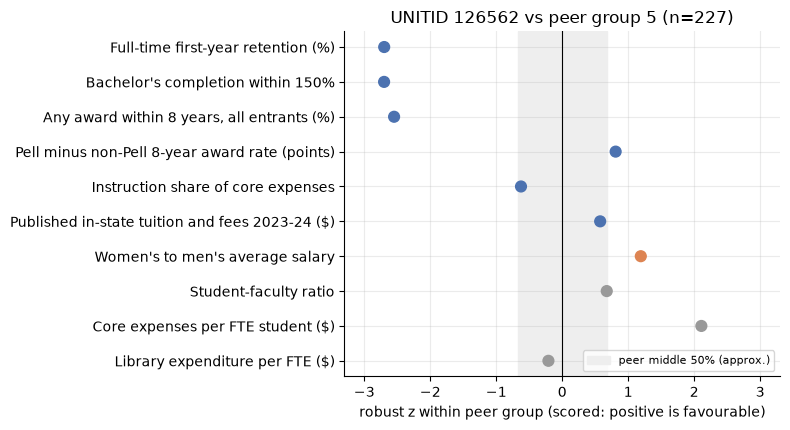

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.4))
sc = scorecard.iloc[::-1].reset_index(drop=True)
colours = sc["role"].map({"scored": "#4C72B0", "flag": "#DD8452", "context": "#999999"})
ax.axvspan(-0.6745, 0.6745, color="#EEEEEE", zorder=0, label="peer middle 50% (approx.)")
ax.axvline(0, color="k", lw=0.8)
ax.scatter(sc["oriented z"], range(len(sc)), c=colours, s=60, zorder=3)
ax.set_yticks(range(len(sc)), sc["indicator"])
ax.set(xlim=(-3.3, 3.3), xlabel="robust z within peer group (scored: positive is favourable)",
       title=f"UNITID {FOCAL_UNITID} vs peer group {focal_group} (n={len(group)})")
ax.legend(loc="lower right", fontsize=8)
save("10_scorecard")

## 5. Reading the scorecard responsibly

- **Peer fit.** `DIST_TO_CENTRE` from notebook 05 says how typical the focal
  institution is of its group. An institution far from the centre is being compared
  with peers it only loosely resembles, and a hand-built peer set may be better.
- **Mission-driven values.** Spending per FTE at an institution with a medical campus
  reflects clinical and research operations, not undergraduate resources. That is
  why it is context, not scored.
- **Rank intervals.** If the focal rank interval spans much of the group, the
  composite cannot distinguish it from most peers, and the indicator rows are the
  more informative part of the scorecard.
- **Flags.** The salary ratio is unadjusted for rank, field, and tenure status. A
  distance from parity is a prompt for an adjusted analysis, not a finding.

In [10]:
d = frame.loc[FOCAL_UNITID, "DIST_TO_CENTRE"]
pct = (group["DIST_TO_CENTRE"] < d).mean()
print(f"focal distance to peer-group centre: {d:.2f} (farther than {pct:.0%} of its peers)")

focal distance to peer-group centre: 1.96 (farther than 44% of its peers)


**What this scorecard shows for the focal institution.** CU Denver/Anschutz sits in
the high-resource research group alongside flagship publics and selective privates.
It is not unusually far from the group centre, closer than 56% of its peers.
The clustering features put it there, mainly through spending per FTE, which the
medical campus inflates to more than twice the peer median. Its average salary is
actually below the group median. On the
three completion measures it sits near the bottom of that group, about 20 points
below the peer median on retention and more than 30 on six-year and eight-year
completion. Pell students, however, complete slightly better than other students
(+1 point against a peer median of -5), and in-state tuition is in the cheapest
fifth of the group.

Both readings are correct, and the tension between them is the lesson. A peer model
built on resource features compares a combined urban-commuter and medical campus with
residential flagships. Their students differ in ways the resource features do not
capture: part-time and transfer enrollment, first-generation share, and admissions
selectivity. The composite rank (189 of 207, with a 90% interval of 97 to 201) says
more about that peer choice than about institutional performance. Before using a
scorecard like this, compare it with a peer set built on student-body features or
chosen by the institution (exercise 1).

## Exercises

1. Rebuild the scorecard with Carnegie basic classification as the peer group. Which
   indicator positions change most, and what does that say about peer choice?
2. Replace equal weights with weights elicited from a stakeholder, then report where
   that weighting falls in the Dirichlet distribution of ranks.
3. Tighten the coverage rule to all six indicators. Which institutions drop out, and
   is their absence random?